# **Data Science Project**

# **Analysis of Daily Entry and Exit Data for Public Transport using Tube and Rail Stations (2024-2025)**

# **a) Project Summary:**

- The purpose of this project is to analyse and forecast daily passenger Footfall at `London Underground` and `Rail Stations` using historical `Entry & Exit between 2024-2025`.

- To better understand travel patterns and demand trends, the study will employ data science and time series forecasting techniques.

# **b) Aim:**
- The Aim is to create a forecasting pipeline for Daily Footfall data at Transport Stations.

# **c) Research Question:**
- How do daily entry and exit footfall patterns in public transport stations? Change over time in 2024-2025?

#**1. Library Imports and Analytical Setup**

- The Cell imports required Python Libraries for a Full Transport Footfall Forecasting Workflow, including `Data Handling`, `Plotting`, `Forecasting`, `Performance Evaluation`, and `Machine Learning`.

- `Numpy & Pandas` are required for the purpose of **Numerical Computations, Data Handling, and Analysis** of structured Tabular Data.

- `Matplotlib` and `Seaborn` are necessary packages for the Plotting Trend Graphs, Anomaly Detection Plots, and Forecasting Model Comparison Plots.

- `Statsmodels` is necessary for Classical Time Series Forecasting Techniques like `Holt-Winters Exponential Smoothing` and `SARIMA/SARIMAX.`

- `XGBoost` is necessary for Machine Learning-based Forecasting Benchmarking so that the cell is able to compare classical statistical forecasting models with the machine learning models.

In [ ]:
# 1. Library Imports and Analytical Setup

# standard Library
from __future__ import annotations

import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple

# Data + Plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# forecasting models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Machine Learning
import xgboost as xgb

# **2. Data Loading, Cleaning and Footfall COnstruction**

- This cell loads the raw station footfall dataset and performs the initial preprocessing required before analysis

- The dataset is read from a CSV file and column names are cleaned to removed any unnecessary whitespace

- The `TravelDate` column is converted to datetime format to enable time-series ordering, plotting and forecasting.

- Invalid or missing date records are removed to ensure the dataset's analytical reliability.

- The `EntryTapCount` and `ExitTapCount` columns are converted to numeric format and missing values are replaced with zero.

- A new total demand variable `Footfall` is then created by adding the entry and exit counts for each record.

- Finally, the dataset is sorted by `Station` and `TravelDate` to create a clean, chronologically ordered dataframe suitable for downstream modelling.

In [ ]:
# Data Loading, Cleaning and Footfall Construction

# load CSV
df = pd.read_csv("/content/StationFootfall_2024_2025 .csv")

# clean column names
df.columns = df.columns.str.strip()

# parse TravelDate
df["TravelDate"] = pd.to_datetime(df['TravelDate'].astype(str), errors='coerce')

# Drops rows where TravelDate could not be parsed
df = df.dropna(subset=["TravelDate"]).copy()

# Make sure Tap Counts are Numeric
df["EntryTapCount"] = pd.to_numeric(df["EntryTapCount"], errors='coerce').fillna(0)
df["ExitTapCount"] = pd.to_numeric(df["ExitTapCount"], errors='coerce').fillna(0)

# create Footfall
df["Footfall"] = df["EntryTapCount"] + df["ExitTapCount"]

# Basic Tidy
df = df.sort_values(["Station", "TravelDate"]).reset_index(drop=True)
df

,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount,Footfall
0,2024-01-01,Monday,Abbey Road DLR,395,375,770
1,2024-01-02,Tuesday,Abbey Road DLR,689,661,1350
2,2024-01-03,Wednesday,Abbey Road DLR,781,797,1578
3,2024-01-04,Thursday,Abbey Road DLR,859,848,1707
4,2024-01-05,Friday,Abbey Road DLR,844,783,1627
...,...,...,...,...,...,...
311442,2025-12-21,Sunday,Woolwich Elizabeth Line,13149,12147,25296
311443,2025-12-22,Monday,Woolwich Elizabeth Line,18007,17403,35410
311444,2025-12-23,Tuesday,Woolwich Elizabeth Line,17662,16726,34388
311445,2025-12-24,Wednesday,Woolwich Elizabeth Line,13474,12963,26437


# **3. Station Name Resolution**

- This cell defines a station matching utility to help standardise the user specified name against the official station name in the data set.

- If the station name contains spelling errors, the function uses exact matching, case insensitive matching or fuzzy matching.

- THis increases the processes robustness, especially when manually selecting stations for analysis.

- In this project, this resolver function resloves the requested stations `Kings Cross St Pancras` and `Roding Valley`.

- This section will produce a mapping dictionary that links the requested input names to the closest valid station names.

In [ ]:
# 3. Station Name Resolution
from difflib import get_close_matches
from typing import List, Dict, Optional

def resolve_stations(
    df:pd.DataFrame,
    requested: List[str],
    n_matches: int = 3,
    cutoff: float = 0.5
):

  # Clean + build station Universe Once
    universe = (
        df["Station"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    universe.sort()

    # case insensitive lookup (fast exact match ignoring case)
    lower_lookup = {name.lower(): name for name in universe}

    mapping: Dict[str, Optional[str]] = {}

    for name in requested:
        name_clean = str(name).strip()
        name_lower = name_clean.lower()

        # 1) Exact Match
        if name_clean in universe:
            mapping[name] = name_clean
            continue

        # 2) Exact Match
        if name_lower in lower_lookup:
            mapping[name] = lower_lookup[name_lower]
            continue

        # 3) Fuzzy Match
        close = get_close_matches(name_clean, universe, n = n_matches, cutoff = cutoff)
        mapping[name] = close[0] if close else None

    return mapping

stations_wanted = ["Kings Cross St Pancras","Roding Valley"]

stations_map = resolve_stations(df, stations_wanted)
stations_map

{'Kings Cross St Pancras': 'Kings Cross St Pancras',
 'Roding Valley': 'Roding Valley'}

# **4. Filtering the Dataset to Selected Stations**

- This cell filters the main data set to keep only the stations we want to analyze.

- Once we have the **station names**, only those stations remain.

- The new dataframe contains our target stations, removing noise from our data set and ensuring that our `trend`, `anomaly`, and `forecast analyzes` are focused correctly.

- This filtered data subset will be our **new working** set for the remainder of this notebook.

In [ ]:
# 4. Filtering the Dataset to Selected Stations

# keep only the station names that were successfully resolved
selected = [name for name in stations_map.values() if name]

# filter the dataframe to just those stations
df2 = df[df["Station"].isin(selected)].copy()

df2["Station"].dropna().unique()

array(['Kings Cross St Pancras', 'Roding Valley'], dtype=object)

# **5. Daily Reindexing, Calender Features and Missing-Value imputation**

- In this section, the data from each station is properly prepared for `time-series modelling`.


- Multiple entries for the same date are combined into a **single entry** with a **single footfall value**.

- The station data is then **reindexed** over the entire range of dates.

- `Calendar-based features` are added to the dataset.


- Missing footfall values are then estimated based on whether the day is a weekday or not, followed by time interpolation.


- This section is critical because the models that will be used, such as `Holt-Winters`, `SARIMA`, and `XGBoost`, require clean and complete time-series data.


- This section produces a cleaned and enhanced dataframe called `df2_full`.

In [ ]:
# 5. Daily Reindexing, Calender Features and Missing-Value imputation

DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
TARGET_COL = "Footfall"

def add_calander_cols(s: pd.DataFrame):
    d = s["TravelDate"].dt

    s["DayOfWeek"] = pd.Categorical(d.day_name(), categories = DOW_ORDER, ordered = True)
    s["Dow"] = d.dayofweek
    s["is_weekend"] = (s["Dow"] >= 5).astype(int)
    s["month"] = d.month
    s["day"] = d.day
    s["weekofyear"] = d.isocalendar().week.astype(int)

    return s

def reindex_impute_station(station_df: pd.DataFrame):
    s = station_df.copy()
    station_name = s["Station"].iloc[0]

    # 1. Combine Duplicates
    s = (
        s.groupby("TravelDate", as_index = False)
         .agg({
             TARGET_COL: "sum",
             "EntryTapCount": "sum",
             "ExitTapCount": "sum",
         })
         .sort_values("TravelDate")
    )

    # 2. Reindex to a continuous daily date range
    s = s.set_index("TravelDate")
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(full_idx)
    s.index.name = "TravelDate"

    # Restore Station after Reindex
    s["Station"] = station_name

    # counts: missing days means 0 tap
    for col in ["EntryTapCount","ExitTapCount"]:
        if col in s.columns:
            s[col] = s[col].fillna(0)

    # 3. Calendar columns
    s = s.reset_index()
    s = add_calander_cols(s)

    # 4. Impute Footfall
    weekly_median = s.groupby("Dow")[TARGET_COL].median()
    overall_median = s[TARGET_COL].median()

    missing = s[TARGET_COL].isna()
    s.loc[missing, TARGET_COL] = s.loc[missing, "Dow"].map(weekly_median)

    # if still missing
    s[TARGET_COL] = s[TARGET_COL].fillna(overall_median)

    # Time Interpolation
    s = s.set_index("TravelDate")
    s[TARGET_COL] = s[TARGET_COL].interpolate(method = "time", limit_direction = "both")
    s[TARGET_COL]  = s[TARGET_COL] .ffill().bfill().fillna(0)

    return s.reset_index()

# create the 'Footfall' column by summing EntryTapCount and ExitTapCount
df["Footfall"] = df["EntryTapCount"] + df["ExitTapCount"]

df2_full = (
    df.groupby("Station", group_keys = False)
     .apply(reindex_impute_station)
     .reset_index(drop = True)
)

for col in ["EntryTapCount","ExitTapCount", TARGET_COL]:
    df2_full[col] = df2_full[col].round().astype("int64")

df2_full

/tmp/ipykernel_715/1377671783.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(reindex_impute_station)


,TravelDate,Footfall,EntryTapCount,ExitTapCount,Station,DayOfWeek,Dow,is_weekend,month,day,weekofyear
0,2024-01-01,770,395,375,Abbey Road DLR,Monday,0,0,1,1,1
1,2024-01-02,1350,689,661,Abbey Road DLR,Tuesday,1,0,1,2,1
2,2024-01-03,1578,781,797,Abbey Road DLR,Wednesday,2,0,1,3,1
3,2024-01-04,1707,859,848,Abbey Road DLR,Thursday,3,0,1,4,1
4,2024-01-05,1627,844,783,Abbey Road DLR,Friday,4,0,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...
315341,2025-12-23,34388,17662,16726,Woolwich Elizabeth Line,Tuesday,1,0,12,23,52
315342,2025-12-24,26437,13474,12963,Woolwich Elizabeth Line,Wednesday,2,0,12,24,52
315343,2025-12-25,43792,0,0,Woolwich Elizabeth Line,Thursday,3,0,12,25,52
315344,2025-12-26,41212,0,0,Woolwich Elizabeth Line,Friday,4,0,12,26,52


# **6. Weekly Trend Plot**

- In this section, we'll create a **reusable function** for plotting how `Footfall` changes across stations over time.

- The function will standardise dates to a consistent **datetime** format, arrange them chronologically and plot footfall observations on a line chart.

- setting the **x-axis** to display dates in **monthly intervals** will make time interpretation easier.

- Before we begin modelling, this step will help us understand `Footfall` Behaviour.

In [ ]:
# 6. Weekly Trend Plot

import matplotlib.dates as mdates

def plot_trend(df_station: pd.DataFrame, title: str, month_interval: int=1):
    s = df_station.copy()

    # make sure date is datetime + sorted
    s["TravelDate"] = pd.to_datetime(s["TravelDate"], errors="coerce")
    s = s.dropna(subset = ["TravelDate"]).sort_values("TravelDate")

    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(s["TravelDate"], s["Footfall"], linewidth = 1.9)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Footfall")
    ax.grid()

    # show a tick in every months
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval = month_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

# **6.1 Kings Cross St Pancras - Trend Analysis**

- This cell uses the trend plotting function for `Kings Cross St Pancras`

- The resulting graph depicts the **daily footfall variation** at one of the dataset's busiest stations.

- This helps determine whether the station experiences significant fluctuations, repeating demand patterns or potential structural changes over time.

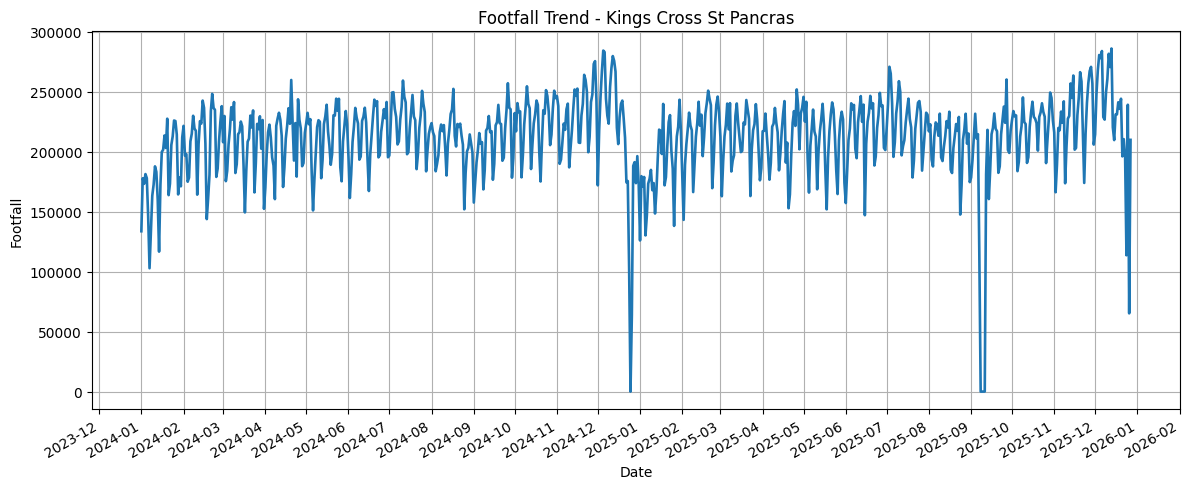

In [ ]:
# 6.1 Kings Cross St Pancras - Trend Analysis

st = "Kings Cross St Pancras"
s = df2_full[df2_full['Station'] == st].copy()
plot_trend(s, f"Footfall Trend - {st}")

# **6.2 Roding Valley - Trend Analysis**

- This cell replicates the process of thrend plotting for `Roding Valley`

- This Plot provides a different perspective on a station demand for a less central location allowing for comparison to a major interchange station.

- This allows for a comparison which is important for the project's overall goal of understanding how forecasting may differ between stations of varying intensity.


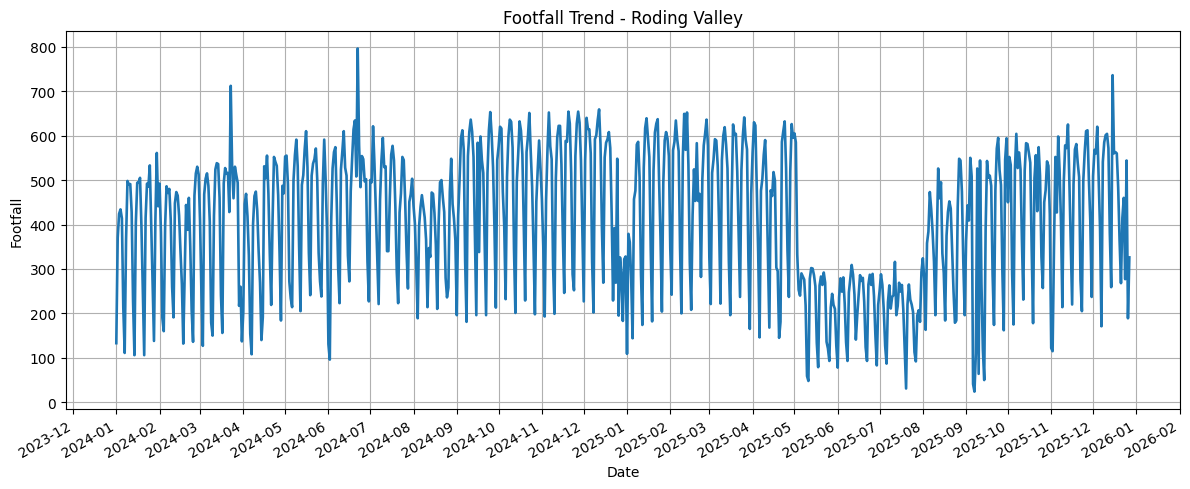

In [ ]:
# 6.2 Roding Valley - Trend Analysis

st = "Roding Valley"
s = df2_full[df2_full['Station'] == st].copy()
plot_trend(s, f"Footfall Trend - {st}")

# **7. Weekday Seasonality Index**

- This cell will be used to calculate the weekday seasonality index, which will help us understand how average footfall changes throughout the week.

- The index is calculated by dividing the average footfall on each day of the week by the overall average footfall at the station.

- If the index is **greater than 1**, it indicates that footfall on that specific day of the week is higher than average.

- If it is **less than 1**, it indicates that footfall is lower than average.

In [ ]:
# 7. Weekday Seasonality Index

def weekday_seasonality_index(df_station: pd.DataFrame):
    overall = df_station["Footfall"].mean()
    tmp = (df_station.groupby("DayOfWeek")["Footfall"].mean()/ overall).reindex(DOW_ORDER)
    return tmp.reset_index().rename(columns = {"Footfall" : "weekday_index"})

# **7.1 Kings Cross St Pancras - Weekday Seasonality**

- This cell calculates and displays the weekday seasonality index for `Kings Cross St Pancras`.

- This graph depicts the demand difference for a well-known London Railway Station on **Weekdays and Weekends**


Kings Cross St Pancras -- Weekday Seasonality Index:


/tmp/ipykernel_715/2510665876.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = (df_station.groupby("DayOfWeek")["Footfall"].mean()/ overall).reindex(DOW_ORDER)


,DayOfWeek,weekday_index
0,Monday,0.893230
1,Tuesday,0.999899
2,Wednesday,1.035555
3,Thursday,1.106185
4,Friday,1.061066
5,Saturday,1.053602
6,Sunday,0.849011


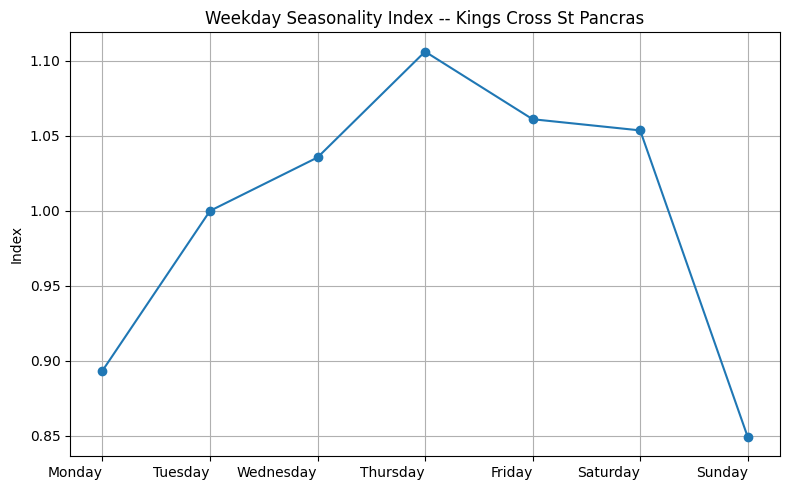

In [ ]:
# 7.1 Kings Cross St Pancras - Weekday Seasonality

st = "Kings Cross St Pancras"
s = df2_full[df2_full["Station"] == st].copy()
idx = weekday_seasonality_index(s)

print(f"\n{st} -- Weekday Seasonality Index:")
display(idx)

plt.figure(figsize =(8,5))
plt.plot(idx["DayOfWeek"], idx["weekday_index"], marker = 'o')
plt.xticks(rotation=0, ha="right")
plt.title(f"Weekday Seasonality Index -- {st}")
plt.ylabel("Index")
plt.tight_layout()
plt.grid()
plt.show()
plt.close()

# **7.2 Roding Valley**

- This cell calculates and displays the weekday seasonality index for 'Roding Valley.'

- This profile will allow us to determine whether this station's seasonality is similar to that of other stations in central London or significantly different.

- This will help us make more informed modelling decisions later on.


Roding Valley -- Weekday Seasonality Index:


/tmp/ipykernel_715/2510665876.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = (df_station.groupby("DayOfWeek")["Footfall"].mean()/ overall).reindex(DOW_ORDER)


,DayOfWeek,weekday_index
0,Monday,1.021287
1,Tuesday,1.210084
2,Wednesday,1.237600
3,Thursday,1.252076
4,Friday,1.075377
5,Saturday,0.732806
6,Sunday,0.465632


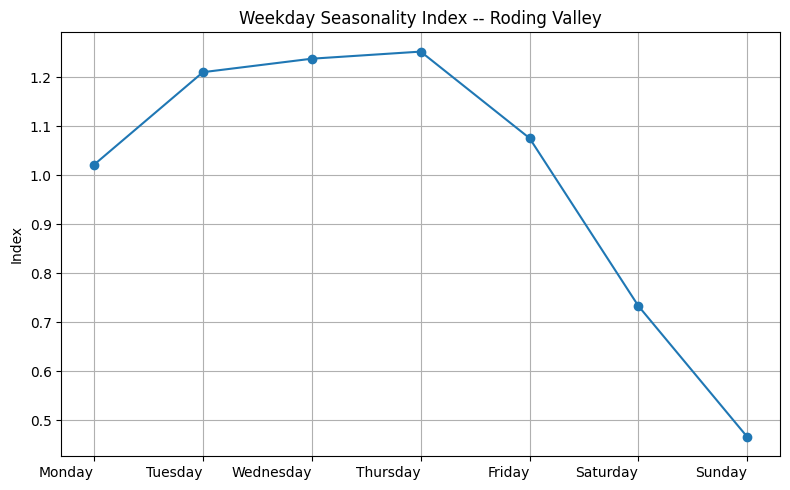

In [ ]:
# 7.2 Roding Valley - Weekday Seasonality

st = "Roding Valley"
s = df2_full[df2_full["Station"] == st].copy()
idx = weekday_seasonality_index(s)

print(f"\n{st} -- Weekday Seasonality Index:")
display(idx)

plt.figure(figsize =(8,5))
plt.plot(idx["DayOfWeek"], idx["weekday_index"], marker = 'o')
plt.xticks(rotation=0, ha="right")
plt.title(f"Weekday Seasonality Index -- {st}")
plt.ylabel("Index")
plt.tight_layout()
plt.grid()
plt.show()
plt.close()

# **8. Robust Z-score Anamoly Detection**

- This section will go over a reliable method for detecting anomalies in data using `median` and `median absolute deviation`.


- The robust z-score is less sensitive to extreme outliers than the `normal z-score`. This makes it more appropriate for use in transportation footfall data.

- Each data point will receive a `robust z-score`. If footfall figures are unusually high or low, they are classified as anomalies if they exceed a specific threshold.

In [ ]:
# 8. Robust Z-Score Anomaly Detection

def robust_zscore(x: pd.Series):
    x = pd.to_numeric(x, errors="coerce")

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))

    # if MAD is zero, return 0 z-scores
    if pd.isna(mad) or mad == 0:
        return pd.Series(0.0, index=x.index)

    return pd.Series(0.6745 * (x - med) / mad, index=x.index)


def detect_anomalies(df_station: pd.DataFrame, z_thresh: float = 3.5):
    s = df_station.copy()

    # make sure Footfall is numeric
    s["Footfall"] = pd.to_numeric(s["Footfall"], errors="coerce")

    s["rz"] = robust_zscore(s["Footfall"])
    s["is_anomaly"] = (s["rz"].abs() >= z_thresh).astype(int)

    return s

# **8.1 Kings Cross St Pancras - Weekly Anomalies**

- This cell detects strong anomalies on `Kings Cross St Pancras` and displays the results on a time series chart.

- The results are highlighted in red, making it easy to **identify unusual traffic patterns**.

- In addition, this cell generates a table with the most **extreme anomaly dates** and their corresponding `robust z-scores`.


Kings Cross St Pancras — anomalies found: 12


,TravelDate,Footfall,rz
156500,2024-12-25,2,-8.275713
156759,2025-09-10,5,-8.275599
156757,2025-09-08,16,-8.275181
156758,2025-09-09,26,-8.274801
156760,2025-09-11,78,-8.272826
156501,2024-12-26,64009,-5.843995
156866,2025-12-26,65203,-5.798633
156499,2024-12-24,101906,-4.404233
156147,2024-01-07,102796,-4.370421
156864,2025-12-24,113595,-3.960152


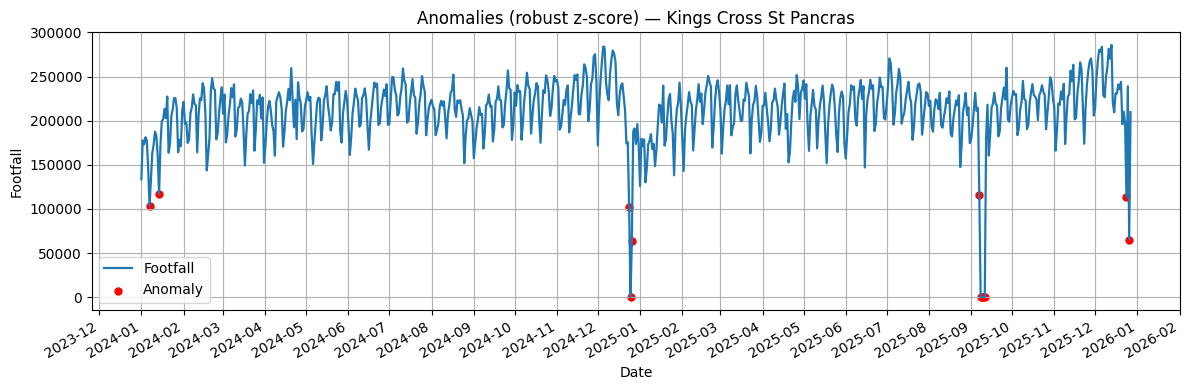

In [ ]:
# 8.1 Kings Cross St Pancras – Weekly Anomalies

import matplotlib.dates as mdates

st = "Kings Cross St Pancras"

# filter station + keep dates clean
s = df2_full[df2_full["Station"] == st].copy()
s["TravelDate"] = pd.to_datetime(s["TravelDate"], errors="coerce")
s = s.dropna(subset=["TravelDate"]).sort_values("TravelDate")

# detect anomalies
s = detect_anomalies(s)

# quick summary
anom_count = int(s["is_anomaly"].sum())
print(f"\n{st} — anomalies found: {anom_count}")

# show top 10 most extreme points
display(
    s.loc[s["is_anomaly"] == 1, ["TravelDate", "Footfall", "rz"]]
     .assign(abs_rz=lambda d: d["rz"].abs())
     .sort_values("abs_rz", ascending=False)
     .drop(columns="abs_rz")
     .head(10)
)

# plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(s["TravelDate"], s["Footfall"], linewidth=1.6, label="Footfall")

anom = s["is_anomaly"] == 1
ax.scatter(
    s.loc[anom, "TravelDate"],
    s.loc[anom, "Footfall"],
    s=25,
    color="red",
    label="Anomaly"
)

ax.set_title(f"Anomalies (robust z-score) — {st}")
ax.set_xlabel("Date")
ax.set_ylabel("Footfall")
ax.grid()
ax.legend()

# x-axis ticks in week to week
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
plt.close()

# **8.2 Roding Valley – Weekly Anomalies**

- This cell employs the same anomaly detection method as in `Roding Valley`.

- This chart illustrates anomalies in passenger count observations and compares them to anomaly behaviour at `Kings Cross St Pancras`.

- This helps determine whether anomalies are more common at stations with lower passenger counts.




Roding Valley — anomalies found: 0


,TravelDate,Footfall,rz


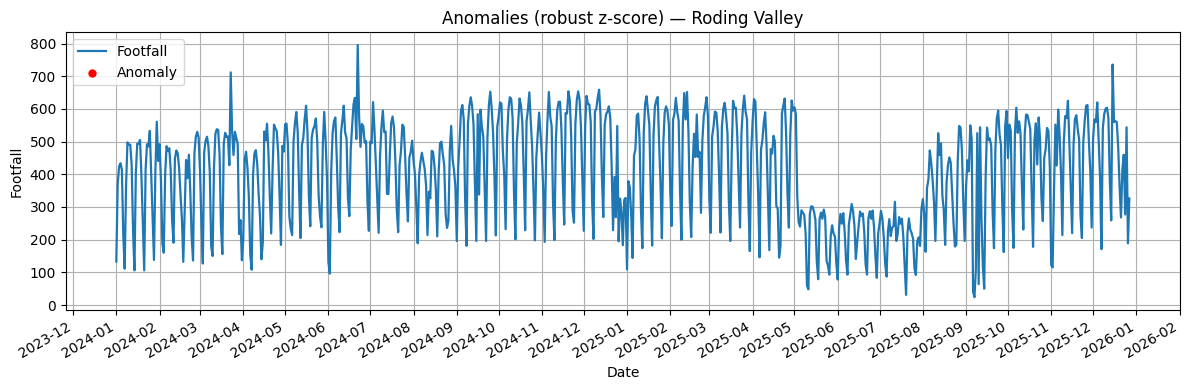

In [ ]:
# 8.2 Roding Valley – Weekly Anomalies

import matplotlib.dates as mdates

st = "Roding Valley"

# filter station + keep dates clean
s = df2_full[df2_full["Station"] == st].copy()
s["TravelDate"] = pd.to_datetime(s["TravelDate"], errors="coerce")
s = s.dropna(subset=["TravelDate"]).sort_values("TravelDate")

# detect anomalies
s = detect_anomalies(s)

# quick summary
anom_count = int(s["is_anomaly"].sum())
print(f"\n{st} — anomalies found: {anom_count}")

# show top 10 most extreme points
display(
    s.loc[s["is_anomaly"] == 1, ["TravelDate", "Footfall", "rz"]]
     .assign(abs_rz=lambda d: d["rz"].abs())
     .sort_values("abs_rz", ascending=False)
     .drop(columns="abs_rz")
     .head(10)
)

# plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(s["TravelDate"], s["Footfall"], linewidth=1.6, label="Footfall")

anom = s["is_anomaly"] == 1
ax.scatter(
    s.loc[anom, "TravelDate"],
    s.loc[anom, "Footfall"],
    s=25,
    color="red",
    label="Anomaly"
)

ax.set_title(f"Anomalies (robust z-score) — {st}")
ax.set_xlabel("Date")
ax.set_ylabel("Footfall")
ax.grid()
ax.legend()

# x-axis ticks in week to week
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
plt.close()

# **9. Train-Test Split and Baseline Forecast**

- This section is used to prepare the forecast framework by dividing the time series of each station into a training and test set.


- The `last 90 days` of the time series are used as a test set to evaluate the model's forecast performance.


- A `seasonal naïve forecast` is created as the baseline forecast, which forecasts demand based on recent weekly patterns.


- Additionally, `MAE`, `RMSE`, `MAPE`, and `sMAPE` are used as metrics to evaluate the accuracy of forecasted values in a consistent manner.


In [ ]:
# 9. Train-Test Split and Baseline Forecast

test_days = 90
seasonal_period = 7

def train_test_split_n(df_station: pd.Dataframe, test_days: int=90):
  s = df_station.sort_values("TravelDate").copy()
  cutoff = s["TravelDate"].max() - pd.Timedelta(days = test_days - 1)
  train = s[s["TravelDate"] < cutoff].copy()
  test = s[s["TravelDate"] >= cutoff].copy()
  return train, test

def seasonal_naive_forecast(train: pd.DataFrame, test: pd.DataFrame, m:int=7):
    y_train = train["Footfall"].values
    if len(y_train) < m:
        return np.full(len(test), np.nan)

    last_season = y_train[-m:]
    reps = int(np.ceil(len(test) / m))
    return np.tile(last_season, reps)[:len(test)]

def metrics(y_true, y_pred):
  y_true = np.asarray(y_true, dtype = float)
  y_pred = np.asarray(y_pred, dtype = float)

  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_absolute_error(y_true, y_pred))

  eps = 1e-9
  mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
  smape = np.mean(
      2 * np.abs(y_true - y_pred) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100

  return {"MAE": mae, "RMSE":rmse, "MAPE%":mape, "sMAPE%":smape}

# **10. Holt–Winters Exponential Smoothing**

- This cell uses the `Holt-Winters Exponential Smoothing model`, which includes an additive trend and additive weekly seasonality.

- The model attempts to `capture levels, trends, and periodicity` in daily footfall data collected from stations.

- A fallback strategy has been included to initialise the model when the preferred estimation strategy is insufficient for the given period.

- This improves the model's robustness and suitability for time series forecasting in transport applications.

In [ ]:
# 10. Holt–Winters Exponential Smoothing

def fit_predict_holt_winters(train: pd.DataFrame, test: pd.DataFrame, m: int=7):
    y_train = train.set_index("TravelDate")["Footfall"].asfreq("D")

    initialization_method_hw = "estimated"

    if len(y_train) < (2 * m):
        warnings.warn(
            f"Not Enough Training Data ({len(y_train)} daily points) for two full seasonal cycles ({2 * m} Daily Points)"
            f"for Holt Winters 'estimated' initialization. Switching to 'legacy-heuristic'."
        )
        initialization_method_hw = "legacy_heuristic"

    model = ExponentialSmoothing(
        y_train,
        trend = "add",
        seasonal = "add",
        seasonal_periods = m,
        initialization_method = initialization_method_hw
    ).fit(optimized = True)

    forecast = model.forecast(len(test))
    return forecast.values

# **11. SARIMA Model with AIC-Based Selection**

- In this section, the `Seasonal ARIMA (SARIMA)` model will be used to forecast weekly seasonal footfall.

- A grid search will be conducted on a list of possible combinations for non-seasonal and seasonal orders.

- The `Akaike Information Criterion (AIC)` will be used to determine the best model by balancing fit and complexity.

- This allows the notebook to choose a more data-driven `SARIMA model` configuration rather than a single model in a predetermined order.

- The model will be fitted to the training data and used to predict the test set.

In [ ]:
# 11. SARIMA Model with AIC-Based Selection

from dataclasses import dataclass
from typing import Tuple, Optional
from itertools import product

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

@dataclass
class SarimaSpec:
  order: Tuple[int, int, int]
  seasonal_order: Tuple[int, int, int, int]   # (P, D, Q, m)

def pick_sarima_by_aic(y_train: pd.Series, m: int=7):

    best_aic = np.inf
    best_spec: Optional[SarimaSpec] = None

    # Small Grid
    p_vals, d_vals, q_vals = [0,1,2], [0,1], [0,1,2]
    P_vals, D_vals, Q_vals = [0,1], [0,1], [0,1]

    # Make sure series is Usuable
    y = pd.to_numeric(y_train, errors="coerce").dropna()

    for (p, d, q, P, D, Q) in product (p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals):
        try:
            model = SARIMAX(
                y,
                order = (p,d,q),
                seasonal_order = (P,D,Q,m),
                enforce_stationarity = False,
                enforce_invertibility = False
            )

            res = model.fit(disp = False)

            if res.aic < best_aic:
                best_aic = res.aic
                best_spec = SarimaSpec(order = (p,d,q), seasonal_order = (P,D,Q,m))

        except Exception:
            continue
    # fallback if everything fails
    return best_spec or SarimaSpec(order=(1, 1, 1), seasonal_order=(1, 1, 0, m))


def fit_predict_sarima(
    train: pd.DataFrame,
    test: pd.DataFrame,
    m: int = 7
):

    tr = train.copy()
    te = test.copy()

    tr["TravelDate"] = pd.to_datetime(tr["TravelDate"], errors="coerce")
    te["TravelDate"] = pd.to_datetime(te["TravelDate"], errors="coerce")
    tr["Footfall"] = pd.to_numeric(tr["Footfall"], errors="coerce")

    tr = tr.dropna(subset=["TravelDate", "Footfall"]).sort_values("TravelDate")
    te = te.dropna(subset=["TravelDate"]).sort_values("TravelDate")

    # daily series; fill gaps to reduce fit errors
    y_train = tr.set_index("TravelDate")["Footfall"].asfreq("D").ffill()

    spec = pick_sarima_by_aic(y_train, m=m)

    model = SARIMAX(
        y_train,
        order=spec.order,
        seasonal_order=spec.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    forecast = res.forecast(steps=len(te))
    return forecast.to_numpy(), spec

# **12. SARIMAX with Exogenous Calendar Features**

- This cell extends the earlier `SARIMA` framework to `SARIMAX`, which includes more external **exogenous predictors**.

- **Exogenous Predictors:** These include `day of week`, `weekend`,`month`, `day`, and `week year`.

- **How is this useful?:** By incorporating the autoregressive seasonal component as well as the `additional external features`, the model can capture both the `time-series periodicity` and the additional external variation.

In [ ]:
# 12. SARIMAX with Exogenous Calendar Features

EXOG_COLS = ["Dow", "is_weekend", "month", "day", "weekofyear"]

def fit_predict_sarimax(train: pd.DataFrame, test: pd.DataFrame, m: int = 7):
    train = train.copy()
    test = test.copy()

    y_train = train.set_index("TravelDate")["Footfall"].asfreq("D")
    X_train = train.set_index("TravelDate")[EXOG_COLS].asfreq("D")
    X_test  = test.set_index("TravelDate")[EXOG_COLS].asfreq("D")

    # pick order based on y only (keeps selection stable + fast)
    spec = pick_sarima_by_aic(y_train, m=m)

    model = SARIMAX(
        y_train,
        exog=X_train,
        order=spec.order,
        seasonal_order=spec.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    forecast = res.forecast(steps=len(test), exog=X_test)
    return forecast.values, spec


# **13. XGBoost Feature Engineering and Prediction**

- This section will look at an alternative machine learning-based forecasting solution called `XGBoost`.

- Lag variables and rolling summary statistics are designed so that the model can learn short-term temporal dependencies using previous footfall data.

- Calendar variables are included in the dataset to help the model learn systematic footfall demand.

- The use of `XGBoost` in this section provides an alternative non-linear solution that can be used to compare to the traditional time series solutions developed in previous sections of the notebook.

- This will allow the project to determine whether boosted decision trees can outperform statistical forecasting solutions on station transport data.

In [ ]:
# 13. XGBoost Feature Engineering and Prediction

def make_lag_features(s: pd.DataFrame, lags=(1,7,14,21,28), rolls=(7,14,28)):
    s = s.sort_values("TravelDate").copy()
    s = s.set_index("TravelDate")

    # lags
    for L in lags:
        s[f"lag_{L}"] = s["Footfall"].shift(L)

    # rolling stats on lagged series to avoid leakage: shift(1) before rolling
    base = s["Footfall"].shift(1)
    for w in rolls:
        s[f"roll_mean_{w}"] = base.rolling(w).mean()
        s[f"roll_std_{w}"]  = base.rolling(w).std()
        s[f"roll_min_{w}"]  = base.rolling(w).min()
        s[f"roll_max_{w}"]  = base.rolling(w).max()

    # back to columns
    s = s.reset_index()
    return s

def fit_predict_xgboost(train: pd.DataFrame, test: pd.DataFrame):
    # build features on concatenated to ensure consistent feature engineering
    all_s = pd.concat([train, test], axis=0).copy()
    all_s = make_lag_features(all_s)

    # split back
    train_idx = all_s["TravelDate"].isin(train["TravelDate"])
    tr = all_s[train_idx].copy()
    te = all_s[~train_idx].copy()

    feature_cols = EXOG_COLS + [c for c in tr.columns if c.startswith(("lag_","roll_"))]

    # drop rows where lag/rolling features are not available
    tr = tr.dropna(subset=feature_cols + ["Footfall"])
    te = te.dropna(subset=feature_cols)

    X_train = tr[feature_cols]
    y_train = tr["Footfall"]
    X_test  = te[feature_cols]

    model = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    pred_df = te[["TravelDate"]].copy()
    pred_df["pred"] = preds

    out = test[["TravelDate"]].merge(pred_df, on="TravelDate", how="left")["pred"]
    out = out.ffill().bfill().values
    return out


## **14. Forecast Comparison and Visual Evaluation**

- In this section, we will discuss how to evaluate the results and compare the forecasting results of all models used during the test period.

- This section compares the models `Seasonal Naive`, `Holt-Winters`,`SARIMA`, `SARIMAX + Calendar`, and `XGBoost`.

- In this section, we will define a common evaluation framework for comparing the forecasting results of all models over the test period.

- A common prediction cleaning function will be used to align the length of the forecast results with the test period before comparing the results to the actual observed footfall.

- The first function will plot the `actual series` alongside the forecast results from each model to show how the models compare.

- The second function calculates the `Model - Actual` differences to show whether the models are over- or under-predicting actual footfall.

- The third function will plot forecast differences to show the errors in each model.

In [ ]:
# 14. Forecast Comparison and Visual Evaluation

import matplotlib.dates as mdates

model_order = ["Seasonal Naive", "Holt Winters", "SARIMA", "SARIMAX + Calendar", "XGBoost"]

def _clean_pred(yhat, n):
    y = np.asarray(yhat, dtype=float).reshape(-1)

    if len(y) > n:
        y = y[:n]
    elif len(y) < n:
        y = np.pad(y, (0, n - len(y)), constant_values=np.nan)

    y[~np.isfinite(y)] = np.nan

    if np.isnan(y).any():
        y = pd.Series(y).interpolate(limit_direction="both").to_numpy()

    y = np.clip(y, 0, None)
    return y


def plot_forecasts(test: pd.DataFrame, preds: dict, title: str):
    t = test.copy()
    t["TravelDate"] = pd.to_datetime(t["TravelDate"], errors="coerce")
    t["Footfall"] = pd.to_numeric(t["Footfall"], errors="coerce")

    t = (
        t.dropna(subset=["TravelDate", "Footfall"])
         .sort_values("TravelDate")
         .drop_duplicates(subset=["TravelDate"])
         .reset_index(drop=True)
    )

    x = t["TravelDate"]
    y_true = t["Footfall"].to_numpy(dtype=float)
    n = len(t)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y_true, label="Actual", linewidth=1.8)

    for name in model_order:
        if name in preds:
            yhat = _clean_pred(preds[name], n)
            ax.plot(x, yhat, label=name)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Footfall")

    locator = mdates.AutoDateLocator(minticks=6, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


def model_minus_actual_table(test: pd.DataFrame, preds: dict) -> pd.DataFrame:
    t = test.copy()
    t["TravelDate"] = pd.to_datetime(t["TravelDate"], errors="coerce")
    t["Footfall"] = pd.to_numeric(t["Footfall"], errors="coerce")

    t = (
        t.dropna(subset=["TravelDate", "Footfall"])
         .sort_values("TravelDate")
         .drop_duplicates(subset=["TravelDate"])
         .reset_index(drop=True)
    )

    out = t[["TravelDate", "Footfall"]].copy()
    out = out.rename(columns={"Footfall": "Actual"})

    actual = out["Actual"].to_numpy(dtype=float)
    n = len(out)

    for name in model_order:
        if name in preds:
            yhat = _clean_pred(preds[name], n)
            out[f"{name} - Actual"] = yhat - actual

    return out


def plot_model_minus_actual(diff_df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(12, 4))

    for name in model_order:
        col = f"{name} - Actual"
        if col in diff_df.columns:
            ax.plot(diff_df["TravelDate"], diff_df[col], label=col)

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Difference")

    locator = mdates.AutoDateLocator(minticks=6, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# **14.1 Kings Cross St Pancras – Forecast Comparison**

- This section evaluates the performance of the `Kings Cross St Pancras` forecasts by comparing actual footfall values to the predictions provided by the five models.

- The first part of the output will show the `actual values` as well as predictions from the `Seasonal Naive`, `Holt-Winters`, `SARIMA`, `SARIMAX + Calendar`, and `XGBoost` models. This allows us to visually inspect the models performance.

- In the second part of the output, the `forecast errors` will be displayed as `Model - Actual`, giving us a better understanding of whether the models over- or under-predict footfall.

- A table displaying the most recent forecast difference is provided, allowing the final dates of the test period to be examined.

- At the end of the section, the `SARIMA` and `SARIMAX` orders used in the selection process will be printed.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


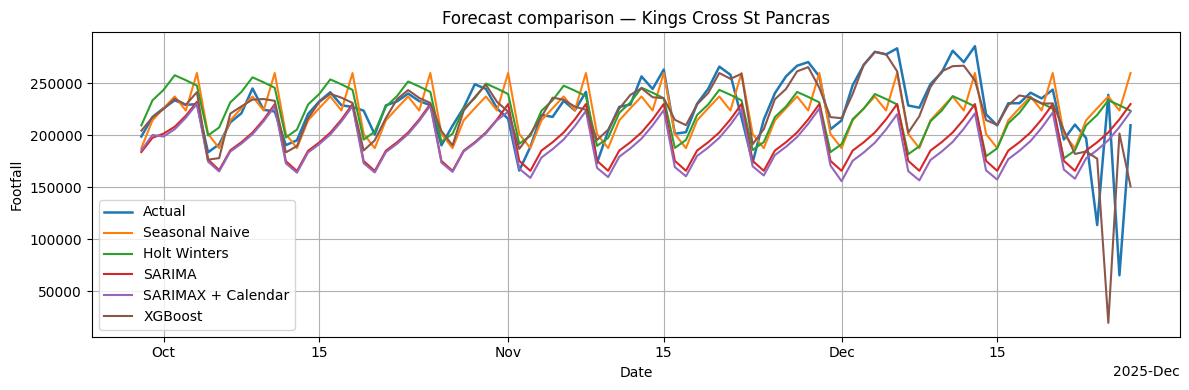

,TravelDate,Actual,Seasonal Naive - Actual,Holt Winters - Actual,SARIMA - Actual,SARIMAX + Calendar - Actual,XGBoost - Actual
0,2025-09-29,198888,-11213.0,10716.091000,-14963.357799,-13299.935312,5620.921875
1,2025-09-30,217582,-3132.0,16124.003009,-19920.454733,-17202.592486,-231.718750
2,2025-10-01,226165,-72.0,17627.770959,-24504.420584,-27345.580393,-865.906250
3,2025-10-02,233724,3696.0,24149.177389,-25471.277399,-27858.963655,1576.859375
4,2025-10-03,229301,-5379.0,23791.692762,-10423.019211,-12375.506936,130.015625
5,2025-10-04,230106,29915.0,17715.969141,2205.324330,338.309499,11501.687500
6,2025-10-05,183668,17654.0,16274.408320,-6966.896361,-8946.423644,-7081.546875
7,2025-10-06,191346,-3671.0,16246.544449,-24842.839206,-26135.356048,-13279.593750
8,2025-10-07,212486,1964.0,19208.456458,-26891.043616,-28153.245236,8412.203125
9,2025-10-08,221236,4857.0,20545.224409,-27854.121494,-29248.344763,6644.359375


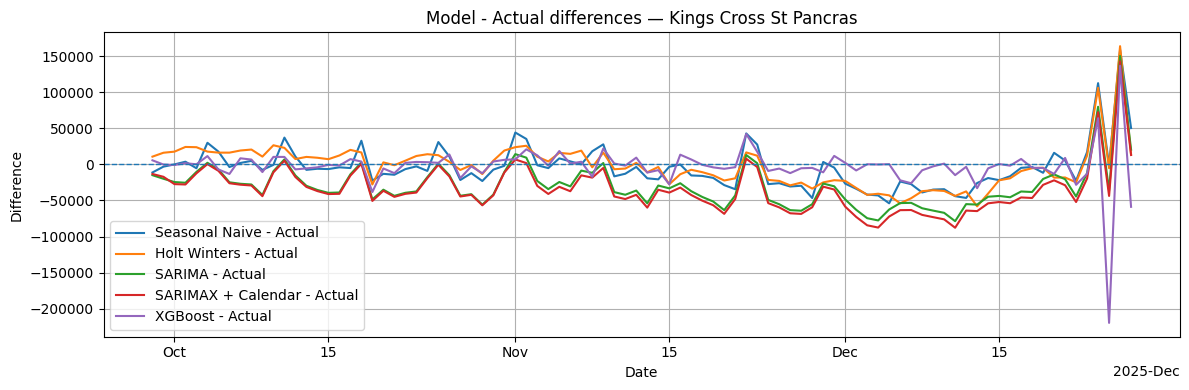


Kings Cross St Pancras SARIMA spec:  order=(2, 0, 2), seasonal=(0, 1, 1, 7)
Kings Cross St Pancras SARIMAX spec: order=(2, 0, 2), seasonal=(0, 1, 1, 7)


In [ ]:
# 14.1 Kings Cross St Pancras – Forecast Comparison

all_preds = {}
all_diffs = {}
specs = {}
results = []

st = "Kings Cross St Pancras"
s = df2_full[df2_full["Station"] == st].copy()
s = s.sort_values("TravelDate").reset_index(drop=True)

train, test = train_test_split_n(s, test_days=test_days)

pred_naive = seasonal_naive_forecast(train, test, m=seasonal_period)
pred_hw = fit_predict_holt_winters(train, test, m=seasonal_period)
pred_sarima, spec_sarima = fit_predict_sarima(train, test, m=seasonal_period)
pred_sarimax, spec_sarimax = fit_predict_sarimax(train, test, m=seasonal_period)
pred_xgb = fit_predict_xgboost(train, test)

preds = {
    "Seasonal Naive": pred_naive,
    "Holt Winters": pred_hw,
    "SARIMA": pred_sarima,
    "SARIMAX + Calendar": pred_sarimax,
    "XGBoost": pred_xgb
}

n_test = len(test)
preds = {name: _clean_pred(yhat, n_test) for name, yhat in preds.items()}

all_preds[st] = preds
specs[st] = {"sarima": spec_sarima, "sarimax": spec_sarimax}

y_true = pd.to_numeric(test["Footfall"], errors="coerce").to_numpy(dtype=float)
for model_name, yhat in preds.items():
    m = metrics(y_true, yhat)
    results.append({"Station": st, "Model": model_name, **m})

plot_forecasts(test, preds, f"Forecast comparison — {st}")

diff_df = model_minus_actual_table(test, preds)
all_diffs[st] = diff_df

display(diff_df.head(10))
plot_model_minus_actual(diff_df, f"Model - Actual differences — {st}")

print(f"\n{st} SARIMA spec:  order={spec_sarima.order}, seasonal={spec_sarima.seasonal_order}")
print(f"{st} SARIMAX spec: order={spec_sarimax.order}, seasonal={spec_sarimax.seasonal_order}")

# **14.2 Roding Valley – Forecast Comparison**

- This cell employs the same forecasting methodology as `Roding Valley` in order to compare actual footfall values to forecasts generated by all five models.

- The first output plot shows the `actual footfall series` alongside forecasts from the `Seasonal Naive, Holt-Winters, SARIMA, SARIMAX+Calendar, and XGBoost` models, allowing for a more direct comparison of each model's ability to follow the pattern of footfall on a weekly basis at a station with lower demand.

- The second output displays the `forecast differences` calculated as `Model - Actual`. Positive differences indicate `overpredicted` values, whereas negative differences indicate `underpredicted` values.

- A table containing the final rows of these differences is also displayed to facilitate examination of the forecast dates.

- This comparison allows us to determine whether forecasting models are consistent and reliable when applied to a station with lower demand and a different variability pattern than `Kings Cross St Pancras`.

- Finally, the selected `SARIMA` and `SARIMAX` model specifications are shown.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

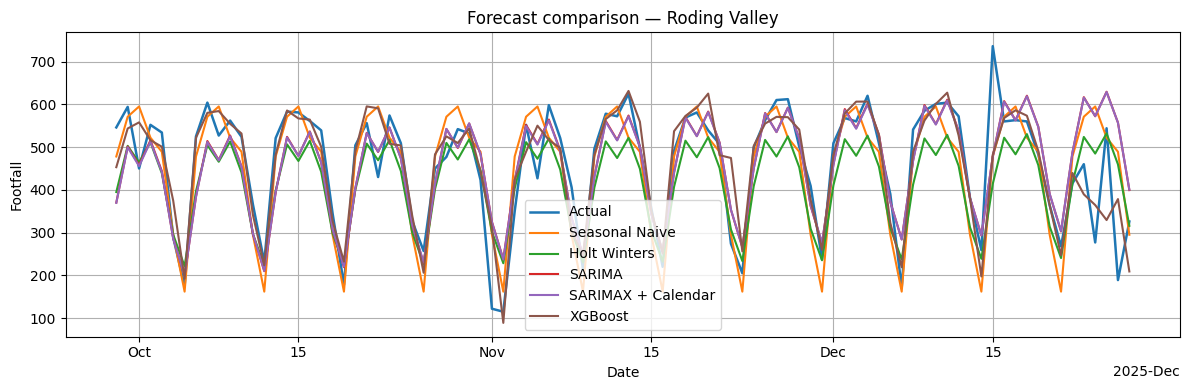

,TravelDate,Actual,Seasonal Naive - Actual,Holt Winters - Actual,SARIMA - Actual,SARIMAX + Calendar - Actual,XGBoost - Actual
0,2025-09-29,546,-68.0,-151.119002,-175.795128,-176.328208,-93.001770
1,2025-09-30,594,-23.0,-91.141925,-92.728228,-94.384058,-50.506165
2,2025-10-01,450,145.0,14.014176,7.715123,5.435329,107.819458
3,2025-10-02,552,-30.0,-40.785494,-36.205763,-39.158930,-35.972839
4,2025-10-03,534,-45.0,-95.223183,-89.981648,-92.244922,-33.114105
5,2025-10-04,289,6.0,6.120160,-2.157030,-2.965133,85.541962
6,2025-10-05,175,-13.0,46.411504,24.630610,24.269133,17.234009
7,2025-10-06,525,-47.0,-128.383314,-140.687182,-141.618907,-3.257812
8,2025-10-07,604,-33.0,-99.406237,-89.844839,-92.053025,-23.921265
9,2025-10-08,527,68.0,-61.250136,-57.315749,-58.162625,57.228516


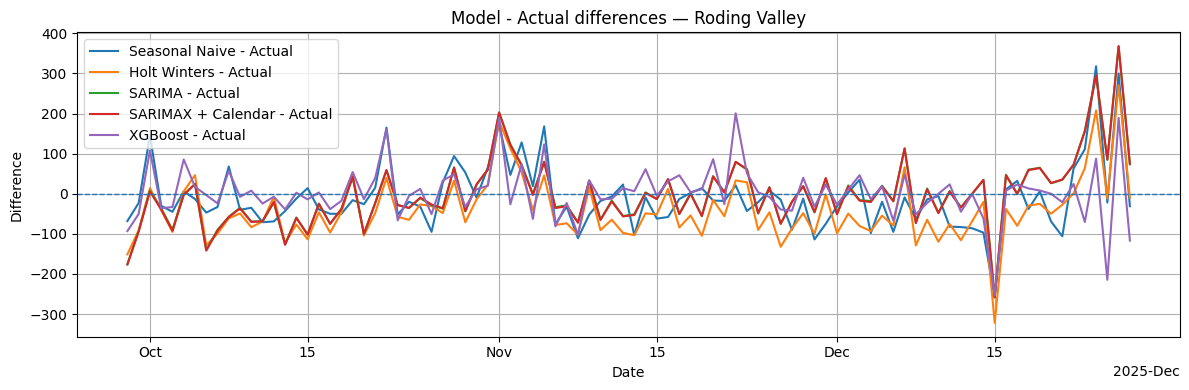


Roding Valley SARIMA spec:  order=(1, 1, 2), seasonal=(0, 1, 1, 7)
Roding Valley SARIMAX spec: order=(1, 1, 2), seasonal=(0, 1, 1, 7)


In [ ]:
# 14.2 Roding Valley – Forecast Comparison

all_preds = {}
all_diffs = {}
specs = {}
results = []

st = "Roding Valley"
s = df2_full[df2_full["Station"] == st].copy()
s = s.sort_values("TravelDate").reset_index(drop=True)

train, test = train_test_split_n(s, test_days=test_days)

pred_naive = seasonal_naive_forecast(train, test, m=seasonal_period)
pred_hw = fit_predict_holt_winters(train, test, m=seasonal_period)
pred_sarima, spec_sarima = fit_predict_sarima(train, test, m=seasonal_period)
pred_sarimax, spec_sarimax = fit_predict_sarimax(train, test, m=seasonal_period)
pred_xgb = fit_predict_xgboost(train, test)

preds = {
    "Seasonal Naive": pred_naive,
    "Holt Winters": pred_hw,
    "SARIMA": pred_sarima,
    "SARIMAX + Calendar": pred_sarimax,
    "XGBoost": pred_xgb
}

n_test = len(test)
preds = {name: _clean_pred(yhat, n_test) for name, yhat in preds.items()}

all_preds[st] = preds
specs[st] = {"sarima": spec_sarima, "sarimax": spec_sarimax}

y_true = pd.to_numeric(test["Footfall"], errors="coerce").to_numpy(dtype=float)
for model_name, yhat in preds.items():
    m = metrics(y_true, yhat)
    results.append({"Station": st, "Model": model_name, **m})

plot_forecasts(test, preds, f"Forecast comparison — {st}")

diff_df = model_minus_actual_table(test, preds)
all_diffs[st] = diff_df

display(diff_df.head(10))
plot_model_minus_actual(diff_df, f"Model - Actual differences — {st}")

print(f"\n{st} SARIMA spec:  order={spec_sarima.order}, seasonal={spec_sarima.seasonal_order}")
print(f"{st} SARIMAX spec: order={spec_sarimax.order}, seasonal={spec_sarimax.seasonal_order}")

# **15. Best Model per Station**

- This section summarises the evaluation results and determines the best forecasting model for each station.

- The `RMSE` is used for comparison because it represents the average magnitude of prediction errors, with larger errors having more severe consequences.

- This allows for a clear conclusion in the notebook regarding which forecasting model is best for each station.

In [ ]:
# 15. Best Model per Station

metrics_df = pd.DataFrame(results)

best_per_stations = (
    metrics_df.sort_values(["Station", "RMSE"])
              .groupby("Station", as_index = False)
              .head()
              .reset_index(drop = True)
)

print("Best Model Per Station (RMSE): ")
best_per_stations

Best Model Per Station (RMSE): 


,Station,Model,MAE,RMSE,MAPE%,sMAPE%
0,Roding Valley,XGBoost,46.176438,6.795325,13.326229,12.063828
1,Roding Valley,Seasonal Naive,57.877778,7.607745,16.708419,15.404066
2,Roding Valley,SARIMA,59.369415,7.705155,17.551939,14.772875
3,Roding Valley,SARIMAX + Calendar,59.540242,7.716232,17.573665,14.808113
4,Roding Valley,Holt Winters,70.632084,8.404290,18.136835,17.046894


# **16. Overall Model Ranking**

- This cell ranks the forecasting models by aggregating the results from multiple stations.

- The average values of `MAE`, `RMSE`, `MAPE`, and `sMAPE` for the various forecasting models are determined.

- This concludes the project by determining the model that performs best overall, rather than for a specific station.

- This ranking would help us identify the most reliable model for forecasting transport demand.

In [ ]:
# 16. Overall Model Ranking

overall = (
    metrics_df.groupby("Model", as_index = False) [["MAE", "RMSE", "MAPE%", "sMAPE%"]]
              .mean()
              .sort_values("RMSE")
)

print("Overall Average Metrics across Selected Stations: ")
overall

Overall Average Metrics across Selected Stations: 


,Model,MAE,RMSE,MAPE%,sMAPE%
4,XGBoost,46.176438,6.795325,13.326229,12.063828
3,Seasonal Naive,57.877778,7.607745,16.708419,15.404066
1,SARIMA,59.369415,7.705155,17.551939,14.772875
2,SARIMAX + Calendar,59.540242,7.716232,17.573665,14.808113
0,Holt Winters,70.632084,8.404290,18.136835,17.046894


# **17. Anomaly Summary per Station**

- The final section of the notebook `summarises the anomalies` for all of the selected stations.

- It displays the number of `anomalies, the anomaly rate , and the highest and lowest robust z-score` for each station.

- This section provides a brief summary of the anomalies at each station, demonstrating the behaviour of unusual demand patterns.

- This information is useful in understanding operational anomalies, as described in the earlier sections of this notebook where forecasting results were interpreted.

In [81]:
# 17. Anomaly Summary per Station

anomaly_summary = []

for st in selected:
    s = df2_full[df2_full["Station"] == st].copy()
    s = detect_anomalies(s)

    anomaly_summary.append({
        "Station": st,
        "AnomalyCount": int(s["is_anomaly"].sum()),
        "AnomalyRate%": float(s["is_anomaly"].mean() * 100),
        "MaxRobustZ": float(s["rz"].max()),
        "MinRobustZ": float(s["rz"].min())

    })

pd.DataFrame(anomaly_summary).sort_values("AnomalyCount", ascending = False)

,Station,AnomalyCount,AnomalyRate%,MaxRobustZ,MinRobustZ
0,Kings Cross St Pancras,12,1.650619,2.584368,-8.275713
1,Roding Valley,0,0.000000,1.919309,-2.314138
